## **DBSCAN - Density-Based Spatial Clustering of Applications with Noise:**

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that groups together points that are closely packed together, marking points located in low-density regions as outliers.

Unlike K-Means, which assumes clusters are spherical and requires the user to specify the number of clusters ($k$), **DBSCAN identifies clusters based on the density of data points and can find clusters of arbitrary shapes**.

### Core Parameters
DBSCAN relies on two key parameters:
1.  **Epsilon ($\epsilon$):** The maximum distance (radius) between two points for them to be considered neighbors.
2.  **MinPts:** The minimum number of points required to form a "dense" region.

### Point Classifications
Every point in the dataset is categorized into one of three types:
*   **Core Points:** A point that has at least `MinPts` within its $\epsilon$-radius. These points form the interior of a cluster.
*   **Border Points:** A point that has fewer than `MinPts` within its $\epsilon$-radius but is within the $\epsilon$-radius of a Core Point. These points lie on the edges of a cluster.
*   **Noise Points (Outliers):** A point that is neither a Core Point nor a Border Point.

### How It Works
1.  Pick an unvisited point.
2.  If the point is a Core Point, a new cluster is started.
3.  All points within the $\epsilon$-radius are added to the cluster.
4.  If those new points are also Core Points, their neighbors are also added to the cluster, expanding it iteratively.
5.  If a point does not meet the density requirement and is not near a Core Point, it is labeled as noise.
6.  Repeat until all points are visited.

### Advantages and Disadvantages
**Advantages:**
*   **Arbitrary Shapes:** Can find non-linear, complex cluster shapes (e.g., crescents or rings).
*   **No $k$ required:** You do not need to specify the number of clusters beforehand.
*   **Robust to Outliers:** Explicitly identifies and ignores noise.

**Disadvantages:**
*   **Varying Densities:** Struggles when clusters have significantly different densities (a single $\epsilon$ cannot capture both dense and sparse clusters).
*   **Parameter Sensitivity:** Results can change drastically with small changes to $\epsilon$ or `MinPts`.
*   **High Dimensionality:** Performance degrades in high-dimensional spaces due to the "curse of dimensionality."

## DBSCAN package from sklearn:

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

# Example: transaction features
# [transaction_amount, time_since_last_txn, merchant_risk_score, distance_from_home]
X = np.array([
    [50, 1, 0.2, 5],      # Normal
    [55, 1.5, 0.2, 4],    # Normal (core point if eps~10, minPts=3)
    [52, 0.8, 0.25, 6],   # Normal (border point)
    [10000, 0.1, 0.8, 500],  # Fraud (noise/outlier)
    [48, 1.2, 0.2, 5.5],  # Normal
    [9500, 0.05, 0.9, 600],  # Fraud (noise)
])

# Normalize features (important for distance-based algorithms)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=3)
labels = dbscan.fit_predict(X_scaled) # there is no training for the unsupervised learning

print("Cluster labels:", labels)
# Output: [-1  0  0 -1  0 -1]
# Interpretation:
# - Points 1, 2, 4 belong to cluster 0 (normal transactions)
# - Points 0, 3, 5 are noise (-1) — potential anomalies

# Identify fraudulent transactions
fraud_mask = labels == -1
print("Suspicious transactions:", X[fraud_mask])

Cluster labels: [ 0 -1  0 -1  0 -1]
Suspicious transactions: [[5.5e+01 1.5e+00 2.0e-01 4.0e+00]
 [1.0e+04 1.0e-01 8.0e-01 5.0e+02]
 [9.5e+03 5.0e-02 9.0e-01 6.0e+02]]


## DBSCAN for Iris Dataset:

In [119]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

### Only use two features

unique classess: [0 1]


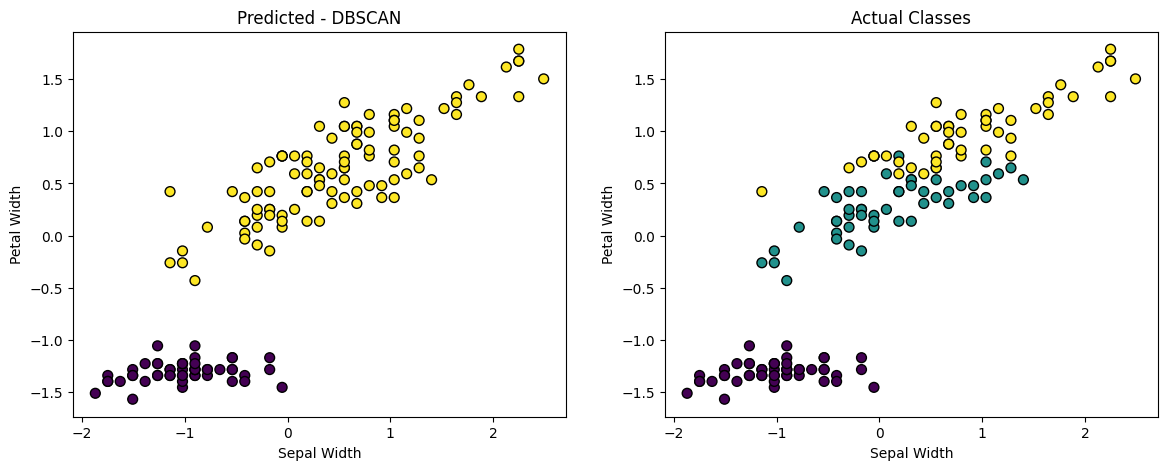

In [102]:
iris = datasets.load_iris(return_X_y=True)
# only use sepal width and petal width for the data as two dimensions
X, y = iris[0][:,[0,2]], iris[1]

# need to standardlize the data for the Euclidean Distance calculation
standard = StandardScaler()
X_std = standard.fit_transform(X)


# fit to the models
model = DBSCAN(eps=0.5, min_samples=5)
y_pred = model.fit_predict(X_std)
print(f'unique classess: {np.unique(y_pred)}')


fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].scatter(X_std[:, 0], X_std[:, 1], c = y_pred, cmap='viridis', edgecolors='k', s=50)
axes[0].set_title('Predicted - DBSCAN')
axes[0].set_xlabel('Sepal Width')
axes[0].set_ylabel('Petal Width')

axes[1].scatter(X_std[:, 0], X_std[:, 1], c = y, cmap='viridis', edgecolors='k', s=50)
axes[1].set_title('Actual Classes')
axes[1].set_xlabel('Sepal Width')
axes[1].set_ylabel('Petal Width')
plt.show()

### Use all features:

unique classess: [-1  0  1  2]


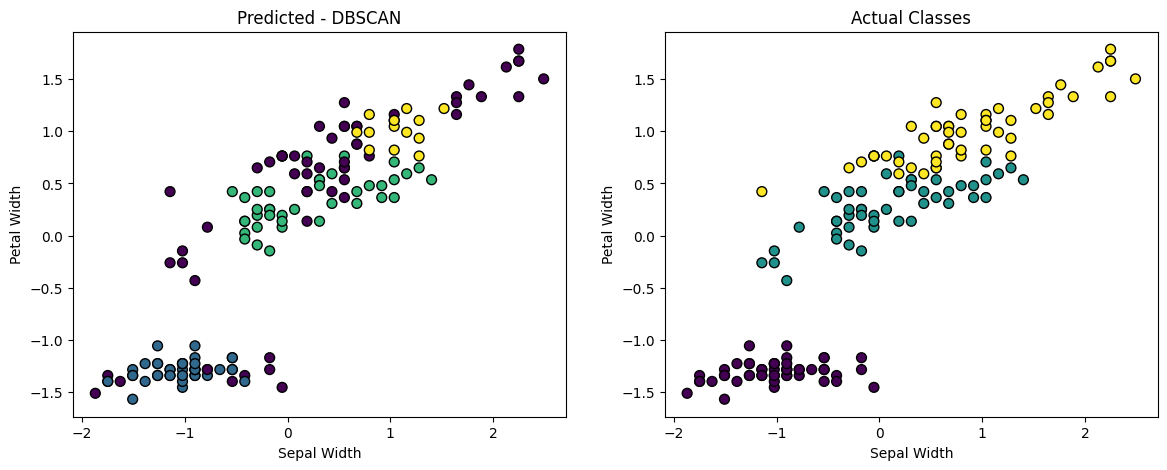

In [112]:
iris = datasets.load_iris(return_X_y=True)
# only use sepal width and petal width for the data as two dimensions
X, y = iris[0], iris[1]

# need to standardlize the data for the Euclidean Distance calculation
standard = StandardScaler()
X_std = standard.fit_transform(X)


# fit to the models
model = DBSCAN(eps=0.45, min_samples=5)
y_pred = model.fit_predict(X_std)
print(f'unique classess: {np.unique(y_pred)}')


fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].scatter(X_std[:, 0], X_std[:, 2], c = y_pred, cmap='viridis', edgecolors='k', s=50)
axes[0].set_title('Predicted - DBSCAN')
axes[0].set_xlabel('Sepal Width')
axes[0].set_ylabel('Petal Width')

axes[1].scatter(X_std[:, 0], X_std[:, 2], c = y, cmap='viridis', edgecolors='k', s=50)
axes[1].set_title('Actual Classes')
axes[1].set_xlabel('Sepal Width')
axes[1].set_ylabel('Petal Width')
plt.show()

In [118]:
accuracy = (y == y_pred).sum()/len(y)
print(f'Model Accuracy: {accuracy:.3f}')

Model Accuracy: 0.627


### **fine-tuning:**

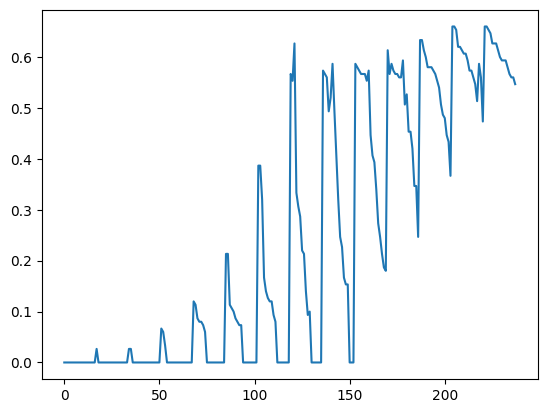

In [159]:
epsilon = np.arange(0.1, 0.8, 0.05)
min_samples = np.arange(3, 20)
accuracies = []
iter = []
# fit to the models
for eps in epsilon:
    for samples in min_samples:
        model = DBSCAN(eps=eps, min_samples=samples)
        y_pred = model.fit_predict(X_std)
        accuracy = (y == y_pred).sum()/len(y)
        iter.append((eps, samples))
        accuracies.append(accuracy)
plt.plot(accuracies);